In [1]:
import pickle
import matplotlib.pyplot as plt
import numpy as np

# Load both result files
with open("training_results.pkl", "rb") as f:
    res1 = pickle.load(f)

with open("training_results_var_thresh.pkl", "rb") as f:
    res2 = pickle.load(f)

# Extract data
train_loss1 = res1["train_loss_history"]
val_loss1 = res1["val_loss_history"]
train_loss2 = res2["train_loss_history"]
val_loss2 = res2["val_loss_history"]

metrics1 = res1["test_metrics"]
metrics2 = res2["test_metrics"]


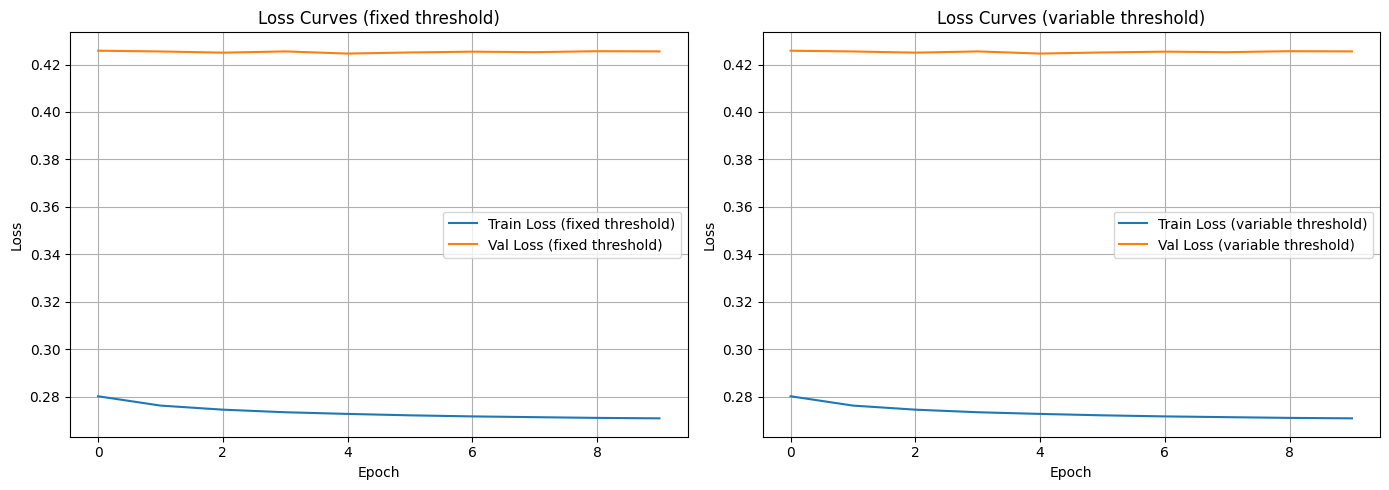

In [2]:

# Plot loss curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_loss1, label='Train Loss (fixed threshold)')
axes[0].plot(val_loss1, label='Val Loss (fixed threshold)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss Curves (fixed threshold)')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(train_loss2, label='Train Loss (variable threshold)')
axes[1].plot(val_loss2, label='Val Loss (variable threshold)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Loss Curves (variable threshold)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('loss_curves.pdf', dpi=300)
plt.show()


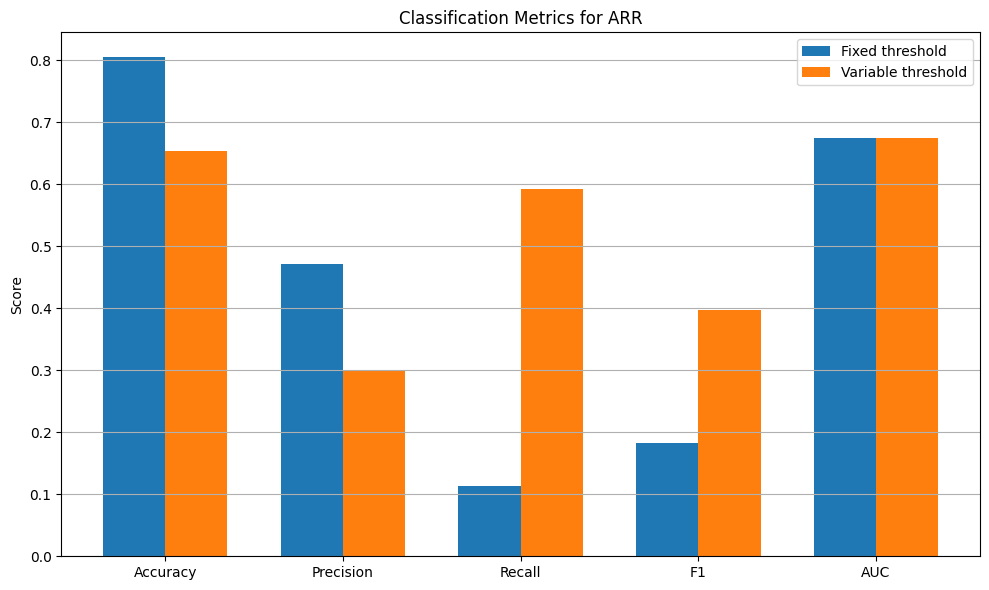

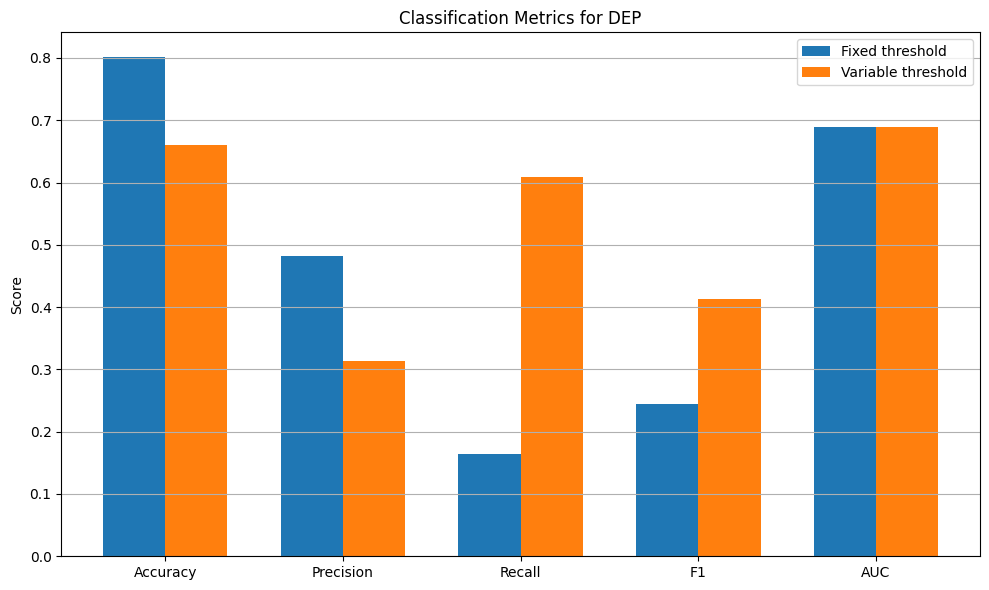

In [3]:

# Plot classification metrics as bar charts for both thresholds
metrics_list = [metrics1, metrics2]
labels = ['Fixed threshold', 'Variable threshold']
targets = ['arr', 'dep']
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']

for target in targets:
    fig, ax = plt.subplots(figsize=(10, 6))
    x = np.arange(len(metrics_names))
    width = 0.35
    for i, (m, lbl) in enumerate(zip(metrics_list, labels)):
        vals = [m[f'{target}_clf'][name] for name in metrics_names]
        ax.bar(x + i*width, vals, width, label=lbl)
    ax.set_xticks(x + width/2)
    ax.set_xticklabels(metrics_names)
    ax.set_ylabel('Score')
    ax.set_title(f'Classification Metrics for {target.upper()}')
    ax.legend()
    ax.grid(True, axis='y')
    plt.tight_layout()
    plt.savefig(f'metrics_{target}.pdf', dpi=300)
    plt.show()


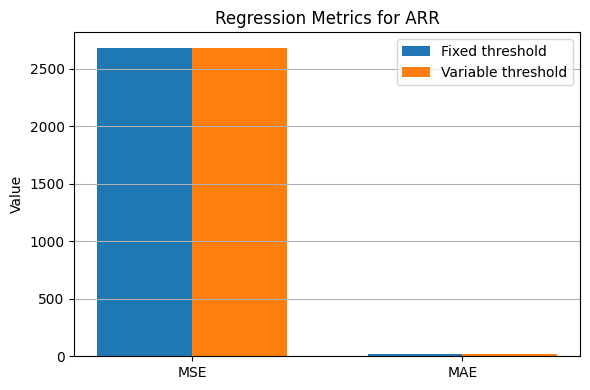

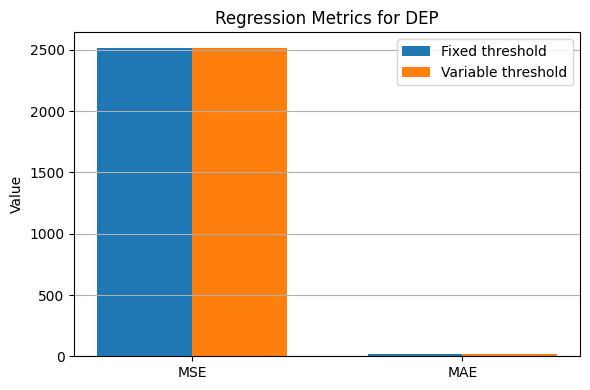

In [4]:

# Regression metrics (MSE, MAE) as bar charts
for target in targets:
    fig, ax = plt.subplots(figsize=(6, 4))
    reg_keys = ['MSE', 'MAE']
    x = np.arange(len(reg_keys))
    width = 0.35
    for i, (m, lbl) in enumerate(zip(metrics_list, labels)):
        vals = [m[f'{target}_reg'][key] for key in reg_keys]
        ax.bar(x + i*width, vals, width, label=lbl)
    ax.set_xticks(x + width/2)
    ax.set_xticklabels(reg_keys)
    ax.set_ylabel('Value')
    ax.set_title(f'Regression Metrics for {target.upper()}')
    ax.legend()
    ax.grid(True, axis='y')
    plt.tight_layout()
    plt.savefig(f'regression_{target}.pdf', dpi=300)
    plt.show()